# **Arabic Sentiment Analysis using Classical Machine Learning**

## **1.Imports & Global Config**

## **1.1 Import Libraries**

In [1]:
# Core
import os
import re
import numpy as np
import pandas as pd
from wordcloud import WordCloud

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem.isri import ISRIStemmer

# ML
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, make_scorer
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.dummy import DummyClassifier

# Models
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from scipy.sparse import hstack

## **1.2 Global Variables**

In [2]:
# Labels
LABELS = {"POS", "NEG", "OBJ", "NEUTRAL"}

# Arabic stopwords
nltk.download('stopwords')
arabic_stopwords = set(stopwords.words('arabic'))
negations = {"مش", "مو", "ما", "ليس", "لا", "لم", "لن", "بدون", "غير"}
arabic_stopwords -= negations

# Stemmer
stemmer = ISRIStemmer()

# Emoji dictionary
EMO_POS = " EMO_POS "
EMO_NEG = " EMO_NEG "
EMO_NEU = " EMO_NEU "

POS_EMOJIS = {
    "😂", "🤣", "😄", "😃", "😊", "😁", "😍", "🥰",
    "❤️", "💖", "💕", "👍", "👏", "🔥"
}

NEG_EMOJIS = {
    "😡", "🤬", "😠", "😢", "😭", "💔",
    "👎", "😞", "😤", "😰", "😨"
}

NEU_EMOJIS = {
    "😐", "😑", "😶", "🙄"
}

# Arabic punctuation
ARABIC_PUNCTUATION = "؟،؛ـ"


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\batol\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## **2. Dataset Loading & Exploration**

### **2.1 Dataset Loading & Conversion to CSV**

In [3]:
# Load TXT dataset and convert to CSV
def convert_to_csv(file_name="Arabic-Tweets_Dataset.txt"):
    data = []
    with open(file_name, "r", encoding="utf-8") as file:
        for line in file:
            line = line.strip()
            if not line:
                continue
            parts = line.rsplit("\t", 1)
            if len(parts) == 2 and parts[1] in LABELS:
                text, label = parts
                data.append([text, label])
            else:
                print("Skipped malformed line:", line)
    df = pd.DataFrame(data, columns=["text", "label"])
    df["label"] = df["label"].replace({"NEUTRAL": "OBJ"})
    df.to_csv("Arabic-Tweets_Dataset.csv", index=False, encoding="utf-8-sig")
    return df

df = convert_to_csv()
df.head()

,text,label
0,بعد استقالة رئيس #المحكمة_الدستورية ننتظر استق...,OBJ
1,أهنئ الدكتور أحمد جمال الدين، القيادي بحزب مصر...,POS
2,البرادعي يستقوى بامريكا مرةاخرى و يرسل عصام ال...,NEG
3,#الحرية_والعدالة | شاهد الآن: #ليلة_الاتحادية ...,OBJ
4,الوالدة لو اقولها بخاطري حشيشة تضحك بس من اقول...,OBJ


### **2.2 Make a copy of the Data for Safety**

In [4]:
df_raw = df.copy()   # Keep this untouched
df = df_raw.copy()   # Work on this copy for preprocessing & feature extraction

## **3. Preprocessing**
**Preprocessing Overview**
We normalize Arabic text, remove elongation, replace emojis with sentiment tokens, handle negation, remove stopwords, and apply stemming to reduce lexical sparsity.

### **3.1 Normalize Arabic Letters**

In [5]:
# Arabic text normalization
def normalize_arabic(text):
    text = re.sub("[إأآا]", "ا", text)
    text = re.sub("ى", "ي", text)
    text = re.sub("ؤ", "و", text)
    text = re.sub("ئ", "ي", text)
    text = re.sub("ة", "ه", text)
    return text

### **3.2 Remove Elongation**

In [6]:
def remove_elongation(text):
    return re.sub(r'(.)\1+', r'\1', text)

### **3.3 Remove URLs, HTML tags, Numbers & Special Characters**

In [7]:
# Remove URLs, HTML tags, and numbers
def clean_text(text):
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)  # remove URLs
    text = re.sub(r"<.*?>", '', text)  # remove HTML tags
    text = re.sub(r"\d+", '', text)    # remove numbers
    text = re.sub(r"[^\w\s#]", '', text)  # remove other punctuation except hashtags
    return text

### **3.4 Replace Emojis**

In [8]:
def replace_emojis(text):
    result = []
    for ch in text:
        if ch in POS_EMOJIS:
            result.append(EMO_POS)
        elif ch in NEG_EMOJIS:
            result.append(EMO_NEG)
        elif ch in NEU_EMOJIS:
            result.append(EMO_NEU)
        else:
            result.append(ch)
    return "".join(result)

### **3.5 Handle Negation**

In [9]:
def handle_negation(text):
    tokens = text.split()
    result = []
    i = 0
    while i < len(tokens):
        if tokens[i] in negations and i+1 < len(tokens):
            result.append("NOT_" + tokens[i+1])
            i += 2
        else:
            result.append(tokens[i])
            i += 1
    return " ".join(result)

### **3.6 Remove Stopwords**

In [10]:
def remove_stopwords(text):
    words = text.split()
    words = [w for w in words if w not in arabic_stopwords]
    return " ".join(words)

### **3.7 Stemming**

In [11]:
def stem_text(text):
    words = text.split()
    return " ".join([stemmer.stem(w) for w in words])

### **3.8 Apply Preprocessing**

In [12]:
def preprocess_text(text):
    # Normalize
    text = normalize_arabic(text)
    
    # Remove elongation
    text = remove_elongation(text)
    
    # Clean text (remove URLs, HTML, numbers, punctuation)
    text = clean_text(text)
    
    # Keep hashtags as separate words
    text = re.sub(r"#(\w+)", r"\1", text)
    
    # Replace emojis with sentiment tokens
    text = replace_emojis(text)
    
    # Handle negation across multiple words (2 words after negation)
    tokens = text.split()
    result = []
    i = 0
    while i < len(tokens):
        if tokens[i] in negations:
            j = i + 1
            while j < min(i+3, len(tokens)):
                tokens[j] = "NOT_" + tokens[j]
                j += 1
            result.append(tokens[i])
            i += 1
        else:
            result.append(tokens[i])
            i += 1
    text = " ".join(result)
    
    # Remove stopwords
    text = remove_stopwords(text)
    
    # Stemming
    text = stem_text(text)
    
    return text

df["cleaned_text"] = df["text"].apply(preprocess_text)
df.head()

,text,label,cleaned_text
0,بعد استقالة رئيس #المحكمة_الدستورية ننتظر استق...,OBJ,قال ريس محكمه_الدستوريه تظر قال ريس_القضاء سود
1,أهنئ الدكتور أحمد جمال الدين، القيادي بحزب مصر...,POS,اهن دكتور حمد جمل دين قيد حزب مصر نسب صدر اول ريت
2,البرادعي يستقوى بامريكا مرةاخرى و يرسل عصام ال...,NEG,ردع سقو بمر مرهاخر رسل عصم عري الي شنط شي قرف
3,#الحرية_والعدالة | شاهد الآن: #ليلة_الاتحادية ...,OBJ,حريه_والعداله شهد الن ليله_الاتحاديه اول يلم ق...
4,الوالدة لو اقولها بخاطري حشيشة تضحك بس من اقول...,OBJ,ولد اقل خطر حشش تضح اقل مل اله وكل تعط حضر فسق...


## **4. Exploratory Data Analysis (EDA)**

#### **4.1 Explore Class Distribution**

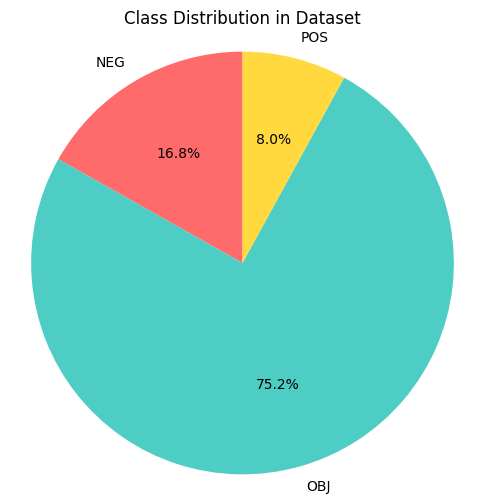

In [13]:
y = df["label"]

# Count number of samples per class
counts = y.value_counts()[["NEG", "OBJ", "POS"]]

plt.figure(figsize=(6,6))
plt.pie(
    counts, 
    labels=counts.index, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=['#FF6B6B','#4ECDC4','#FFD93D']
)
plt.title("Class Distribution in Dataset")
plt.axis('equal')  # Makes the pie circular
plt.show()


### **4.2 Text length distribution per sentiment**

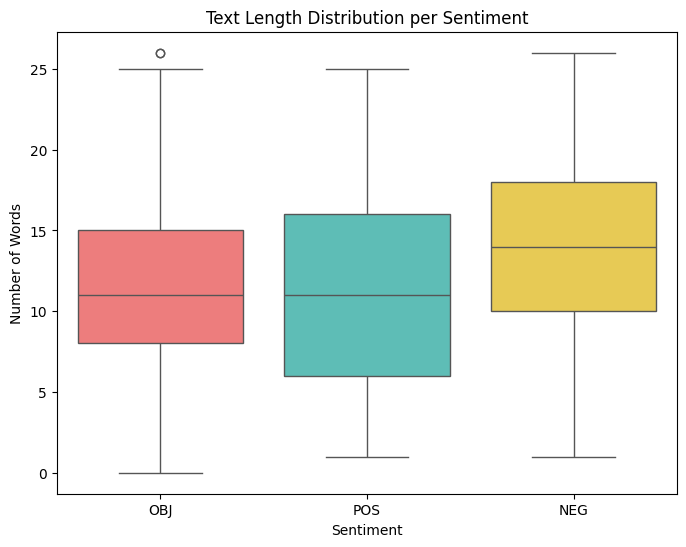

In [14]:
# Add new column for text length
df['text_length'] = df['cleaned_text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(8,6))
sns.boxplot(x='label', y='text_length', data=df, hue='label', palette=['#FF6B6B','#4ECDC4','#FFD93D'])
plt.title("Text Length Distribution per Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Words")
plt.show()


#### **4.3 Word clouds per sentiment**

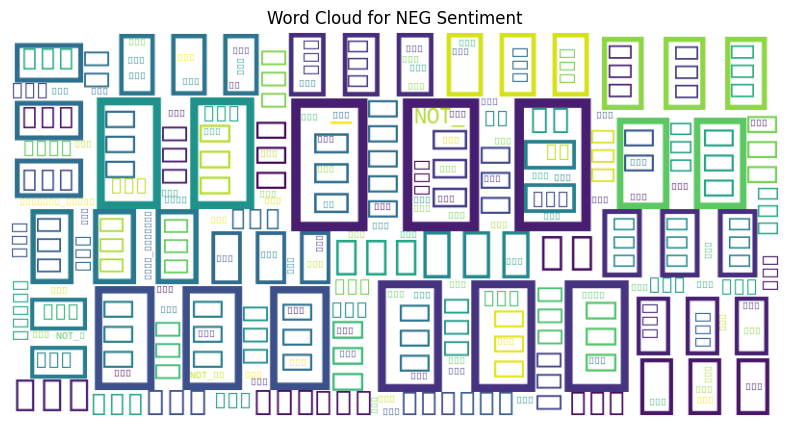

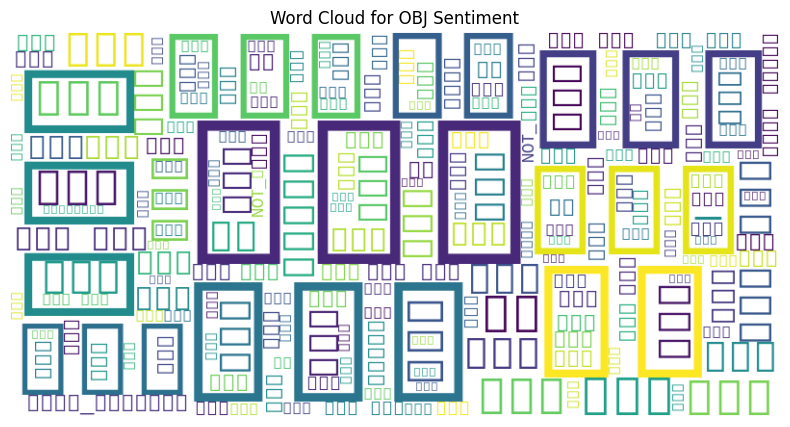

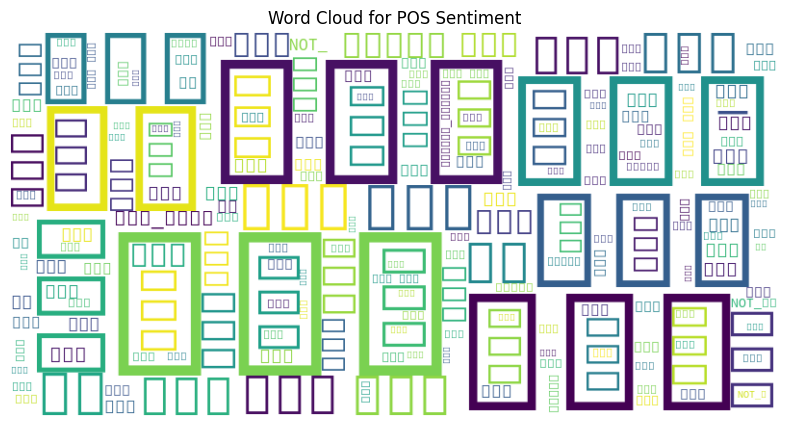

In [15]:
# Function to plot word cloud for a given label
def plot_wordcloud(label):
    text = " ".join(df[df['label']==label]['cleaned_text'])
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(text)
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Word Cloud for {label} Sentiment")
    plt.show()

# Plot for each sentiment
for sentiment in ["NEG","OBJ","POS"]:
    plot_wordcloud(sentiment)

#### **4.4 Negation counts per class**

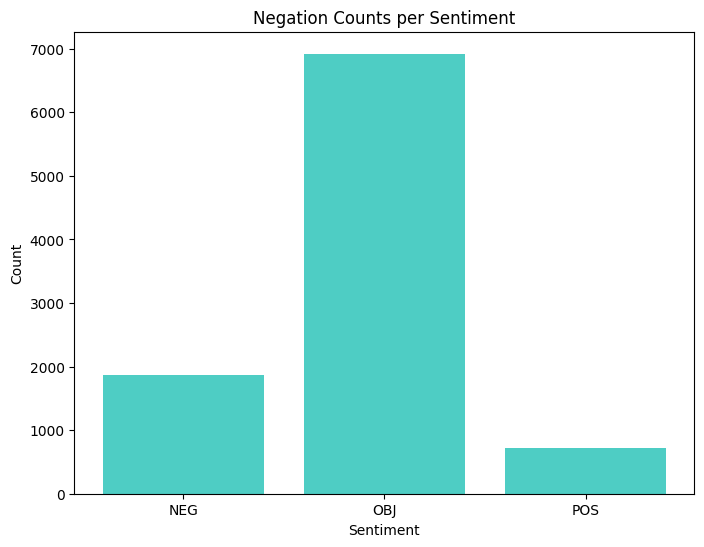

In [16]:
# Negation count
df["neg_count"] = df["cleaned_text"].apply(lambda x: sum(x.count(n) for n in negations))

# Group negation counts by sentiment
negation_stats = df.groupby("label")["neg_count"].sum()

# 5. Plot negation counts
plt.figure(figsize=(8,6))
plt.bar(negation_stats.index, negation_stats.values.astype(int), color="#4ECDC4")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.title("Negation Counts per Sentiment")
plt.show()


## **5. Feature Extraction**
We extract both:
1. **Text-based features** using TF(Term Frequency inside one tweet)-IDF(Inverse Document Frequency meaning in the whole document) (max 2000 features, unigrams and bigrams).
2. **Handcrafted features** specific to Arabic:
   - Negation count
   - Dialect words presence
   - Emoji features

These are combined using `hstack` into a single feature matrix `X`.


### **5.1 TF-IDF Representation**

In [17]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),   # VERY IMPORTANT
    max_features=20000,
    min_df=3,
    max_df=0.9,
    sublinear_tf=True
)

X_tfidf = tfidf.fit_transform(df["cleaned_text"])

### **5.2 Arabic-Specific Feature Functions**

In [18]:
def negation_count(text): 
    return sum(text.count(n) for n in negations)
def dialect_feature(text): 
    return int(any(w in text for w in ["مش","مو","شو","ليش","هيك"]))
def emoji_features(text):
    return pd.Series({"has_positive_emoji": int("EMO_POS" in text),
                      "has_negative_emoji": int("EMO_NEG" in text)})
df["neg_count"] = df["cleaned_text"].apply(negation_count)
df["dialect"] = df["cleaned_text"].apply(dialect_feature)
emoji_df = df["cleaned_text"].apply(emoji_features)
df = pd.concat([df, emoji_df], axis=1)

handcrafted = df[["neg_count","dialect","has_positive_emoji","has_negative_emoji"]].values

### **5.4 Combine Features**

In [19]:
# Combine TF-IDF, and handcrafted features
X = hstack([X_tfidf, handcrafted])
y = df["label"]

print("Final feature matrix shape:", X.shape)

Final feature matrix shape: (10006, 8011)


## **6. Dataset Split**
We split the data into:
- 60% training
- 20% validation
- 20% testing

We use stratified splitting to maintain the class distribution across all sets.

### **6.1 Split Dataset (60-20-20)**

In [20]:
# Split into 60/40, 60% training, 40% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42
)

# Split the 40% temp into 20% tesing, 20% validation
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

### **6.2 Split IF_TDF**
Naïve Bayes is trained only on TF-IDF features, while other models use the combined feature matrix.

In [21]:
X_nb_train, X_nb_temp, y_nb_train, y_nb_temp = train_test_split(
    X_tfidf, y, test_size=0.4, stratify=y, random_state=42
)
X_nb_val, X_nb_test, y_nb_val, y_nb_test = train_test_split(
    X_nb_temp, y_nb_temp, test_size=0.5, stratify=y_nb_temp, random_state=42
)

## **7. Model Training & Validation**

#### Decision Tree
We use a Decision Tree Classifier to model non-linear relationships in the features.  
- Max depth = 10 → controls tree size to reduce overfitting.  
- Min samples split = 2 → minimum samples required to split a node.  
- Min samples leaf = 1 → minimum samples required at a leaf node.  
- Class weights are used to address class imbalance.  
- Feature set: combined features (TF-IDF + handcrafted features).  

#### Random Forest
We use a Random Forest Classifier, an ensemble of decision trees for better generalization.  
- Number of trees (n_estimators) = 100.  
- Max depth = 10, Min samples split = 2, Min samples leaf = 1.  
- Class weights are applied to handle imbalanced classes.  
- Feature set: combined features (TF-IDF + handcrafted features).  

#### Naïve Bayes
We use MultinomialNB, which works well for discrete features like TF-IDF.  
- Alpha = 0.01 → Laplace smoothing to avoid zero probabilities.  
- Fit prior = True → adjusts prior probabilities according to class distribution.  
- Feature set: TF-IDF only.  

#### Neural Network (MLP)
We use a feed-forward multilayer perceptron:  
- Hidden layers: (128, 64) → two layers with decreasing size for hierarchical feature abstraction.  
- Learning rate = 0.001, optimizer = Adam.  
- L2 regularization (alpha = 0.0001) to reduce overfitting.  
- Max iterations = 80 → limits training time; early stopping can be added.  
- Feature set: combined features (TF-IDF + handcrafted features).  
- Class weights are used to improve performance on minority classes.

#### **Compute class weights**

In [22]:
classes = np.unique(y_train)
class_weights_array = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights_array))
print("Class weights:", class_weight_dict)

Class weights: {'NEG': np.float64(1.9811881188118812), 'OBJ': np.float64(0.4433857744294261), 'POS': np.float64(4.16875)}


#### **Compute Macro F1 Scorer**

In [23]:
f1_macro_scorer = make_scorer(
    f1_score,
    average="macro",
    labels=["NEG", "OBJ", "POS"],
    zero_division=0
)


#### **Model Validation Function**

In [24]:
def evaluate_on_validation(name, model, X_val, y_val):
    y_pred = model.predict(X_val)
    print(f"\n--- {name} (Validation) ---")
    print("Accuracy:", accuracy_score(y_val, y_pred))
    print(classification_report(y_val, y_pred, target_names=["NEG","OBJ","POS"]))

#### **GridSearchCV Function**

In [25]:
def run_grid_search(model, param_grid, X_train, y_train, cv_splits=3):
    cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=42)
    grid = GridSearchCV(
        model,
        param_grid,
        scoring=f1_macro_scorer,
        cv=cv,
        verbose=2,
        n_jobs=-1
    )
    grid.fit(X_train, y_train)
    print(f"Best params for {model.__class__.__name__}: {grid.best_params_}\n")
    return grid.best_estimator_

### **7.0 Dummy Model** 

In [26]:
from sklearn.dummy import DummyClassifier

# Baseline model: always predicts the most frequent class (OBJ)
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

y_pred_baseline_val = baseline.predict(X_val)

evaluate_on_validation("Baseline (Majority Class)", baseline, X_val, y_val)

y_pred_baseline_test = baseline.predict(X_test)


--- Baseline (Majority Class) (Validation) ---
Accuracy: 0.7521239380309845
              precision    recall  f1-score   support

         NEG       0.00      0.00      0.00       337
         OBJ       0.75      1.00      0.86      1505
         POS       0.00      0.00      0.00       159

    accuracy                           0.75      2001
   macro avg       0.25      0.33      0.29      2001
weighted avg       0.57      0.75      0.65      2001



C:\Users\batol\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\batol\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\batol\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

### **7.1 Decision Tree**

In [27]:
dt_params = {
    "max_depth": [10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5]
}
best_dt = run_grid_search(
    DecisionTreeClassifier(class_weight=class_weight_dict, random_state=42),
    dt_params,
    X_train, y_train
)

# Validation evaluation 
y_pred_dt_val = best_dt.predict(X_val) 
evaluate_on_validation("Decision Tree", best_dt, X_val, y_val) 
# Test evaluation metric
y_pred_dt_test = best_dt.predict(X_test) 

Fitting 3 folds for each of 27 candidates, totalling 81 fits


C:\Users\batol\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan]
  warnings.warn(


Best params for DecisionTreeClassifier: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}


--- Decision Tree (Validation) ---
Accuracy: 0.7071464267866067
              precision    recall  f1-score   support

         NEG       0.31      0.11      0.16       337
         OBJ       0.76      0.89      0.82      1505
         POS       0.28      0.21      0.24       159

    accuracy                           0.71      2001
   macro avg       0.45      0.40      0.41      2001
weighted avg       0.65      0.71      0.66      2001



### **7.2 Random Forest**

In [28]:
rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [10, 15, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

best_rf = run_grid_search(
    RandomForestClassifier(class_weight=class_weight_dict, random_state=42, n_jobs=-1),
    rf_params,
    X_train, y_train
)

# Validation evaluation
y_pred_rf_val = best_rf.predict(X_val)
evaluate_on_validation("Random Forest", best_rf, X_val, y_val)

# Test evaluation metric
y_pred_rf_test = best_rf.predict(X_test)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


C:\Users\batol\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan]
  warnings.warn(


Best params for RandomForestClassifier: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


--- Random Forest (Validation) ---
Accuracy: 0.6101949025487257
              precision    recall  f1-score   support

         NEG       0.31      0.48      0.37       337
         OBJ       0.81      0.67      0.73      1505
         POS       0.23      0.32      0.27       159

    accuracy                           0.61      2001
   macro avg       0.45      0.49      0.46      2001
weighted avg       0.68      0.61      0.63      2001



### **7.3 Naïve Bayes**

In [29]:
nb_params = {
    "alpha": [0.01, 0.1, 0.5, 1.0],
    "fit_prior": [True, False]
}
best_nb = run_grid_search(
    MultinomialNB(),
    nb_params,
    X_nb_train, y_nb_train
)

# Validation evaluation
y_pred_nb_val = best_nb.predict(X_nb_val)
evaluate_on_validation("Naïve Bayes", best_nb, X_nb_val, y_nb_val)

# Test evaluation metric
y_pred_nb_test = best_nb.predict(X_nb_test)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best params for MultinomialNB: {'alpha': 0.01, 'fit_prior': True}


--- Naïve Bayes (Validation) ---
Accuracy: 0.7401299350324838
              precision    recall  f1-score   support

         NEG       0.41      0.22      0.29       337
         OBJ       0.78      0.92      0.85      1505
         POS       0.40      0.13      0.19       159

    accuracy                           0.74      2001
   macro avg       0.53      0.42      0.44      2001
weighted avg       0.69      0.74      0.70      2001



C:\Users\batol\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan]
  warnings.warn(


### **7.4 Neural Network**

In [30]:
scaler = StandardScaler(with_mean=False)  # sparse matrices
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

best_mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    learning_rate_init=0.001,
    alpha=0.0001,
    max_iter=80,
    random_state=42
)

best_mlp.fit(X_train_scaled, y_train)

# Validation evaluation
y_pred_mlp_val = best_mlp.predict(X_val_scaled)
evaluate_on_validation("MLP Neural Network", best_mlp, X_val_scaled, y_val)

# Test evaluation metric
y_pred_mlp_test = best_mlp.predict(X_test_scaled)


--- MLP Neural Network (Validation) ---
Accuracy: 0.7041479260369815
              precision    recall  f1-score   support

         NEG       0.35      0.28      0.31       337
         OBJ       0.79      0.86      0.82      1505
         POS       0.28      0.14      0.19       159

    accuracy                           0.70      2001
   macro avg       0.47      0.43      0.44      2001
weighted avg       0.67      0.70      0.68      2001



#### **Results Table**

In [31]:
# Now create the models_val dictionary correctly
models_val = {
    "Baseline": y_pred_baseline_val,
    "Decision Tree": y_pred_dt_val,
    "Random Forest": y_pred_rf_val,
    "Naïve Bayes": y_pred_nb_val,
    "MLP Neural Network": y_pred_mlp_val,
}

# Compute results
results_val = []
for name, y_pred in models_val.items():
    acc = accuracy_score(y_val, y_pred)
    f1_macro = f1_score(y_val, y_pred, average='macro')
    results_val.append({
        "Model": name,
        "Accuracy": round(acc, 3),
        "Macro F1": round(f1_macro, 3)
    })

df_results_val = pd.DataFrame(results_val)
print(df_results_val)

                Model  Accuracy  Macro F1
0            Baseline     0.752     0.286
1       Decision Tree     0.707     0.408
2       Random Forest     0.610     0.458
3         Naïve Bayes     0.740     0.442
4  MLP Neural Network     0.704     0.441


## **8. Model Evaluation**
We evaluate models using three metrics:

- **Accuracy**: overall fraction of correct predictions.
- **Classification Report**: includes **precision**, **recall**, and **F1-score** per class.
- **Confusion Matrix**: raw counts of predicted vs actual labels.

#### **Model Evaluation Function**

In [32]:
def evaluate_on_test(model_name, y_true, y_pred):
    print("=" * 60)
    print(f"{model_name} — Test Set Evaluation")
    print("=" * 60)

    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro")
    f1_weighted = f1_score(y_true, y_pred, average="weighted")

    print(f"Accuracy        : {acc:.4f}")
    print(f"F1 Macro (main) : {f1_macro:.4f}")
    print(f"F1 Weighted     : {f1_weighted:.4f}\n")

    print("Classification Report:")
    print(classification_report(y_true, y_pred, digits=4))

    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    
    cm = confusion_matrix(y_true, y_pred, labels=["NEG","OBJ","POS"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["NEG","OBJ","POS"], yticklabels=["NEG","OBJ","POS"])
    plt.title("Confusion Matrix - Naïve Bayes")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show()

### **8.0 Evaluate Baseline Model**

Baseline Model — Test Set Evaluation
Accuracy        : 0.7517
F1 Macro (main) : 0.2861
F1 Weighted     : 0.6452

Classification Report:
              precision    recall  f1-score   support

         NEG     0.0000    0.0000    0.0000       337
         OBJ     0.7517    1.0000    0.8583      1505
         POS     0.0000    0.0000    0.0000       160

    accuracy                         0.7517      2002
   macro avg     0.2506    0.3333    0.2861      2002
weighted avg     0.5651    0.7517    0.6452      2002

Confusion Matrix:
[[   0  337    0]
 [   0 1505    0]
 [   0  160    0]]


C:\Users\batol\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\batol\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\batol\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

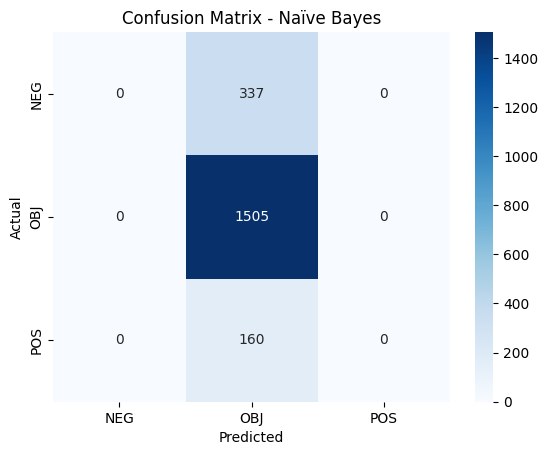

In [33]:
evaluate_on_test("Baseline Model", y_test, y_pred_baseline_test)

### **8.1 Evaluate Decision Tree**

Decision Tree — Test Set Evaluation
Accuracy        : 0.7168
F1 Macro (main) : 0.4339
F1 Weighted     : 0.6829

Classification Report:
              precision    recall  f1-score   support

         NEG     0.4044    0.1632    0.2326       337
         OBJ     0.7766    0.8937    0.8310      1505
         POS     0.2612    0.2188    0.2381       160

    accuracy                         0.7168      2002
   macro avg     0.4807    0.4252    0.4339      2002
weighted avg     0.6727    0.7168    0.6829      2002

Confusion Matrix:
[[  55  271   11]
 [  72 1345   88]
 [   9  116   35]]


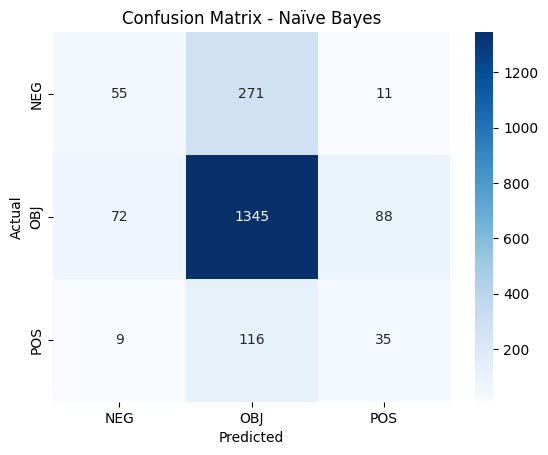

In [34]:
evaluate_on_test("Decision Tree", y_test, y_pred_dt_test)

### **8.2 Evaluate Random Forest**

Random Forest — Test Set Evaluation
Accuracy        : 0.6064
F1 Macro (main) : 0.4741
F1 Weighted     : 0.6347

Classification Report:
              precision    recall  f1-score   support

         NEG     0.3171    0.5401    0.3996       337
         OBJ     0.8222    0.6452    0.7230      1505
         POS     0.2470    0.3812    0.2998       160

    accuracy                         0.6064      2002
   macro avg     0.4621    0.5222    0.4741      2002
weighted avg     0.6912    0.6064    0.6347      2002

Confusion Matrix:
[[182 132  23]
 [371 971 163]
 [ 21  78  61]]


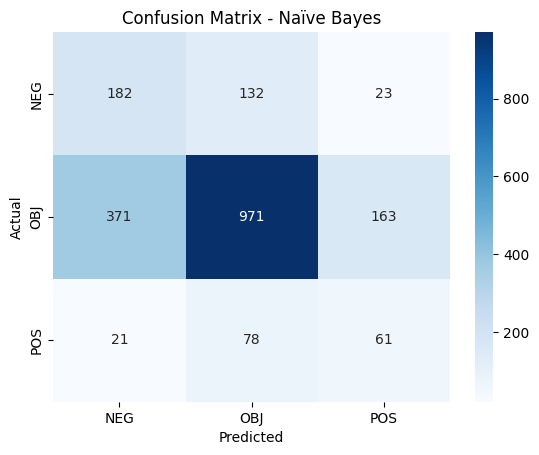

In [35]:
evaluate_on_test("Random Forest", y_test, y_pred_rf_test)

### **8.3 Evaluate Naïve Bayes**

Naïve Bayes — Test Set Evaluation
Accuracy        : 0.7208
F1 Macro (main) : 0.4312
F1 Weighted     : 0.6871

Classification Report:
              precision    recall  f1-score   support

         NEG     0.3831    0.2285    0.2862       337
         OBJ     0.7762    0.8944    0.8311      1505
         POS     0.2985    0.1250    0.1762       160

    accuracy                         0.7208      2002
   macro avg     0.4859    0.4159    0.4312      2002
weighted avg     0.6719    0.7208    0.6871      2002

Confusion Matrix:
[[  77  255    5]
 [ 117 1346   42]
 [   7  133   20]]


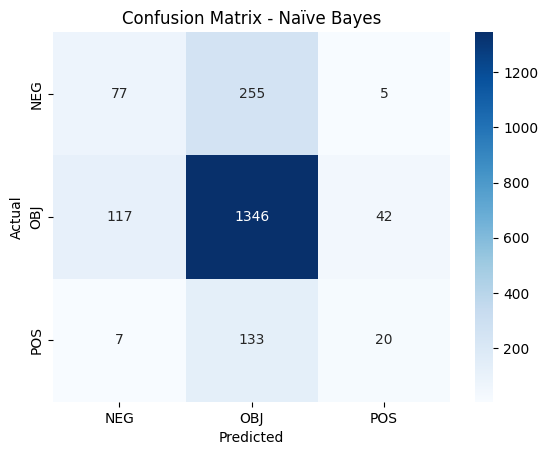

In [36]:
evaluate_on_test("Naïve Bayes", y_nb_test, y_pred_nb_test)

### **8.4 Evaluate Neural Network**

MLP Neural Network — Test Set Evaluation
Accuracy        : 0.6973
F1 Macro (main) : 0.4428
F1 Weighted     : 0.6808

Classification Report:
              precision    recall  f1-score   support

         NEG     0.3617    0.3027    0.3296       337
         OBJ     0.7825    0.8439    0.8120      1505
         POS     0.2474    0.1500    0.1868       160

    accuracy                         0.6973      2002
   macro avg     0.4639    0.4322    0.4428      2002
weighted avg     0.6689    0.6973    0.6808      2002

Confusion Matrix:
[[ 102  227    8]
 [ 170 1270   65]
 [  10  126   24]]


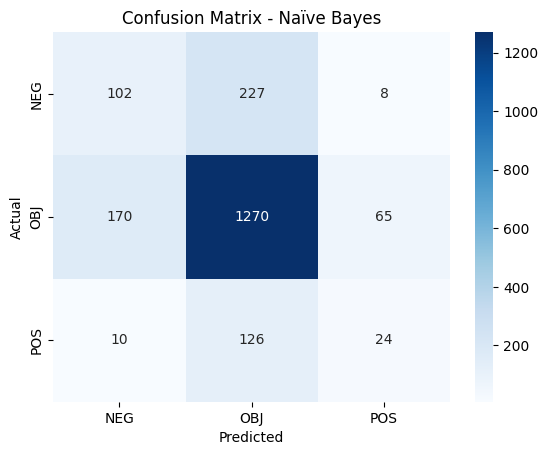

In [37]:
evaluate_on_test("MLP Neural Network", y_test, y_pred_mlp_test)

#### **Results Table**

In [38]:
results = []

# Add each model
models = {
    "Baseline": y_pred_baseline_test,
    "Decision Tree": y_pred_dt_test,
    "Random Forest": y_pred_rf_test,
    "Naïve Bayes": y_pred_nb_test,
    "MLP Neural Network": y_pred_mlp_test
}

for name, y_pred in models.items():
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    results.append({
        "Model": name,
        "Accuracy": round(acc, 3),
        "Macro F1": round(f1_macro, 3)
    })

# Create DataFrame
df_results = pd.DataFrame(results)

# Display nicely
print(df_results)


                Model  Accuracy  Macro F1
0            Baseline     0.752     0.286
1       Decision Tree     0.717     0.434
2       Random Forest     0.606     0.474
3         Naïve Bayes     0.721     0.431
4  MLP Neural Network     0.697     0.443
